In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk import PorterStemmer
from sklearn.model_selection import train_test_split
import collections
import json

# Spam Filter Tutorial Naive Bayesian Classifiers

In this tutorial you are going to use a Naive Bayesian Classifier to distinguish spam emails from other emails. First you are going to build a simple Naive Bayesian Classifier from scratch to get a good intuition of how this type of model works. Next you are asked to build the classifier with scikit-learn.

### Bayes Theorem for spam classification
Similarly as you saw in the bayesian inference tutorial we can fill in Bayes theorem for the spam problem. Only now we want to know what the probability is of an email being spam based on its content.

$P(Spam|Content) = \frac{P(Content|Spam) \cdot P(Spam)}{P(Content)}$

Where:

- \( P(Spam|Content) \) is the **posterior** probability of the mail being spam given its content.
- \( P(Content|Spam) \) is the **likelihood** of the email content given it is spam.
- \( P(Spam) \) is the **prior** probability of spam.
- \( P(Content) \) is the **marginal** probability of the content.

#### Word frequencies
Now we cannot fill in this formula directly because in contrast to the example with coin flips we do not have a single feature (probability heads) but we have text. In this example we are going to use the word frequencies of individual words in email content as features to compute the probability of the content. So in order to find $P(Spam|Content)$ we are going to combine $P(Spam|Word)$ for each word in the content.

#### Assumption of independence
Naive Bayes assumes independence of features, which in our case is independence of word frequencies. Note that this is a strong assumption and a major simplification of natural language structure since there are definitly dependencies between word frequencies in natural language (e.g. road and car cooccur more often than road and spaghetti). Nevertheless, this assumptions allows easy computation of the probability of a sequence of words by simple factorization fo the individual word probabilities:

$$ p=\frac{p_{1} p_{2} \cdots p_{N}}{p_{1} p_{2} \cdots p_{N}+(1-p_{1})(1-p_{2}) \cdots(1-p_{N})} $$

where,
* $ p $ is the probability that the suspect message is spam;
* $ p_{1} $ is the probability $ p(Spam|Word_{1}) $ that it is a spam knowing it contains some first word;
* $ p_{2} $ is the probability $ p(Spam|Word_{2}) $ that it is a spam knowing it contains some second word;
* $ p_{n} $ is the probability $ p(Spam|Word_{N}) $ that it is a spam knowing it contains some Nth word.

#### Computing word probabilities
Now to actually compute $P(Spam|Word)$ we adjust the formula to word level:


$P(Spam|Word) = \frac{P(Word|Spam) \cdot P(Spam)}{P(Word)}$

Where:

- \( P(Spam|Word) \) is the **posterior** probability of the mail being spam given its Word.
- \( P(Word|Spam) \) is the **likelihood** of the email Word given it is spam.
- \( P(Spam) \) is the **prior** probability of spam.
- \( P(Word) \) is the **marginal** probability of the Word.

To compute the marginal probability $P(Word)$ we need to sum the probability of a word occuring in a normal message with the probability of that word occuring in a spam message so:

$P(Spam|Word) = \frac{P(Word|Spam) \cdot P(Spam)}{P(Word|Normal)*P(Normal) + P(Word|Spam)*P(Spam)}$

Since we want the classifier to be unbiased towards spam and normal messages we set $P(Spam) = P(Normal) = 0.5$ meaning the classifier assumes spam emails are as likely as normal emails. In that case the formula can be simplified to:

$P(Spam|Word) = \frac{P(Word|Spam)}{P(Word|Normal) + P(Word|Spam)}$

where,
* $ P(Word|Spam) $ is the number of spam messages containing the word.
* $ P(Word|Normal) + P(Word|Spam) $ is the number of overall messages containing the word.

### Classification
Classification now comes down to computing $P(Spam|Word) $ for each word in a message, factorizing these probabilities and deciding whether the probability of the message being spam is above a certain threshold, lets say 0.5.

### Corrections to prevent instability

#### 1. Factorizing probabilities may lead to very small numbers very fast
In order to avoid floating-point underflow, we are going to use the alternative form of the formula where the log of word probabilities is used instead. Here, almost zero numbers become negatives instead.
$$ p=\frac{1}{1+e^{\eta}} $$
where,
$$ \eta = \sum_{i=1}^{N}[\ln(1-p_{i})-\ln p_{i}] $$

#### 2. Zero probability
What happens if we get a word that was never encountered in the learning phase? We get $ \frac{0}{0} $. That's why we're going to ignore such words. This is of course a simplification as these words may still contain information about whether a message is spam or not and we discard that information.

#### 3. Rare words
Rare words can also cause problems to our calculation as there probability estimates may not be correct. A way to deal with this is to use a corrected probability that is weighted by the frequency of the word in the dataset. In other words, if a word is very rare we lean to the prior probability of spam (P(s)), if a word is more frequent we lean towards the probability of spam given the word P(S|W).


$$ P'(S | W) = \frac{s \cdot P( S ) + n \cdot P(S | W)}{s  + n}, $$
where,

* $ P'(S | W) $ is the corrected probability for the message to be spam, knowing that it contains a given word;
* $ s $  is the strength we give to background information about incoming spam;
* $ P(S) $ is the probability of any incoming message to be spam;
* $ n $ is the number of occurrences of this word during the learning phase;
* $ P(S|W) $ is the spaminess of this word.

## Dataset

In this tutorial you are going to work with an email dataset. This dataset consists emails with each a label (True if spam, False otherwise) and content.

In [2]:
data = pd.read_csv('spam.csv', encoding = 'latin-1')
data.drop(columns=['Unnamed: 2', 'Unnamed: 3','Unnamed: 4'], inplace=True)
data.rename(columns={'v1': 'spam', 'v2' : 'content'}, inplace=True)
data['spam'] = data['spam'].apply(lambda x: True if x == 'spam' else False)
data.head()

,spam,content
0,False,"Go until jurong point, crazy.. Available only ..."
1,False,Ok lar... Joking wif u oni...
2,True,Free entry in 2 a wkly comp to win FA Cup fina...
3,False,U dun say so early hor... U c already then say...
4,False,"Nah I don't think he goes to usf, he lives aro..."


Lets first see how many of the emails in the dataset are spam.

In [3]:
data['spam'].value_counts()

spam
False    4825
True      747
Name: count, dtype: int64

### Train test split
And make a train test split so we can train the model on the training dataset and evaluate its accuracy on the test dataset. Note that 'training' in Naïve Bayes reference to computing probabilites.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(data['content'], data['spam'], test_size=0.33, random_state=42)

### Visualize data

In order to classify the emails correctly we are going to make use of the individual words in the emails. For example, "password" may be an indication of a Fishing email, while the name of a friend of family member may be an indication of a normal email. Below the word counts of individual words (features) are visualized.

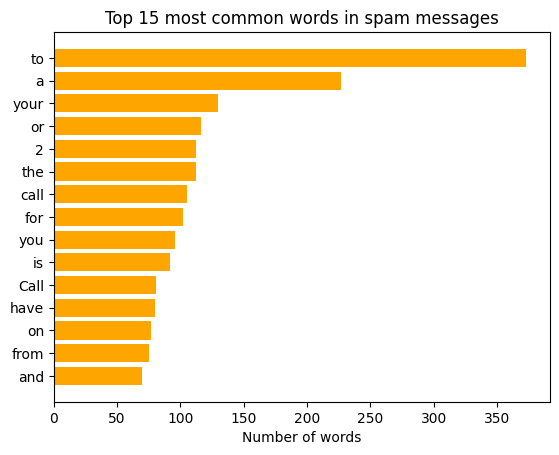

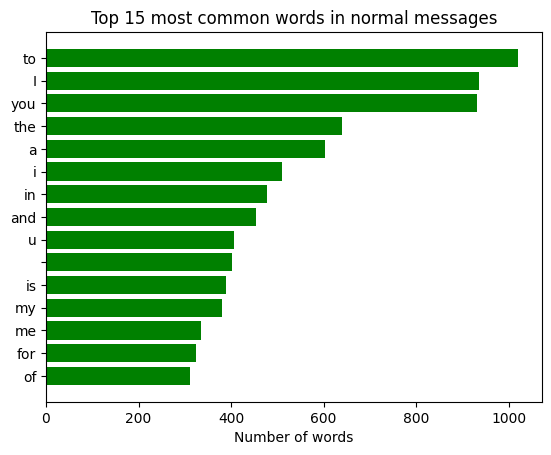

In [5]:
def count_words(data):
    counter = collections.OrderedDict()
    for message in data:
        for word in message.split(' '):
            if word in counter:
                counter[word] += 1
            else:
                counter[word] = 1
    return counter

spam_messages = set(X_train[y_train == True])
spam_words = count_words(spam_messages)
normal_messages = set(X_train[y_train == False])
normal_words = count_words(normal_messages)

def bar_chart_words(words, top=10, messages_type="", color="#1f77b4"):
    top_spam = np.array(sorted(words.items(), key=lambda x: -x[1]))[:top]
    top_words = top_spam[ : :-1, 0]
    top_words_count = [int(i) for i in top_spam[ : :-1, 1]]
    # aesthetics
    if messages_type:
        messages_type = messages_type + " "
    plt.title(f"Top {top} most common words in {messages_type}messages")
    plt.xlabel(f"Number of words")
    plt.barh(top_words, top_words_count, color=color)
    plt.show()

bar_chart_words(spam_words, top=15, messages_type="spam", color="orange")
bar_chart_words(normal_words, top=15, messages_type="normal", color="green")

### Preprocessing text data

You can see there is a lot of overlap in the 15 most common words in both groups and also that it are seemingly common and uninformative words. When working with wordcounts usually a few preprocessing steps are undertaken:

1. Lowercase all words so House and house are counted as a single word.
2. Tokenization of the text so that each text is split into single words that can be counted (without punctuation or spaces).
3. Remove stop words from the message. Stopwords are words that are present a lot in natural language but not very informative such as: the, a, an, to, etc. which are not informative on word level. These can be removed by using a pre-defined stopword list.
4. Remove non-existing words. Some e-mails may contain non-existing words for example from a downloadlink. These can be removed by using a pre-defined vocabulary of all English words.
4. Stemming of words were different verb and noun forms are mapped to the same 'stem'. For example, houses and housed would become house, while go, goes and going would all become go. There are algorithms for stemming purposes, we will use the Porter Stemmer algorithm for this.

Below we update the count words function by incorporating the preprocessing steps above.


In [6]:
#load english wordlist
with open('words_dictionary.json', 'r') as file:
    wordlist = list(json.load(file).keys())

#load english stopwords
with open('stopwords.txt', 'r') as file:
    stop_words = [line.strip() for line in file]

#function to preprocess email content
def preprocess_content(content):
    words = content.lower() #lowercase
    words = words.split() #tokenize by spaces
    words = [word for word in words if len(word) > 1] # remove words of one letter, since these are generally not informative
    words = [word for word in words if word not in stop_words] # remove stopwords
    words = [word for word in words if word in wordlist] # remove non English words
    words = [PorterStemmer().stem(word) for word in words] # Apply stemming
    return words

Below you can see an example of the original and preprocessed email content of an email.

In [7]:
print("\nBefore preprocessing:")
print(X_train[7])

print("\nAfter preprocessing:")
print(preprocess_content(X_train[7]))



Before preprocessing:
As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune

After preprocessing:
['per', 'request', 'set', 'press', 'copi', 'friend']


Now lets adjust the wordcount function with preprocessing steps.

In [8]:
def count_processed_words(data):
    counter = collections.OrderedDict()
    for content in data:
        words = preprocess_content(content)
        for word in set(words):
            if word in counter:
                counter[word] += 1
            else:
                counter[word] = 1
    return counter

And visualize the new top 15 most common words in spam and normal messages

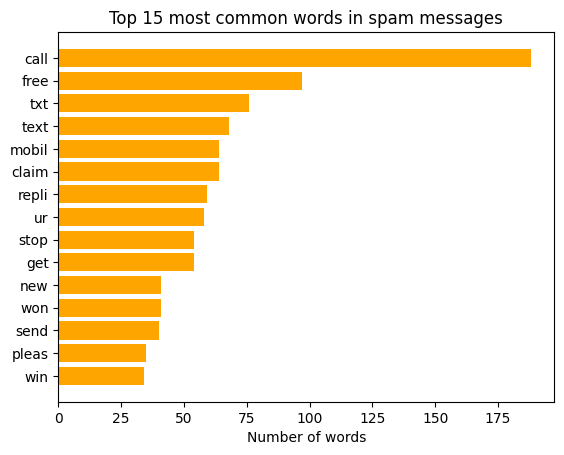

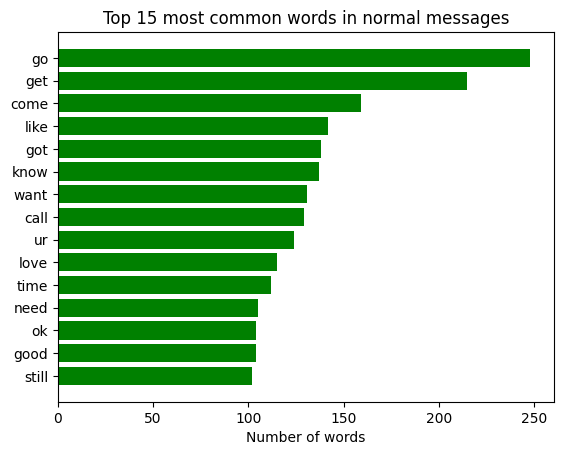

In [9]:
spam_content = set(X_train[y_train == True])
spam_words = count_processed_words(spam_content)
normal_content = set(X_train[y_train == False])
normal_words = count_processed_words(normal_content)

def bar_chart_words(words, top=10, messages_type="", color="#1f77b4"):
    top_spam = np.array(sorted(words.items(), key=lambda x: -x[1]))[:top]
    top_words = top_spam[ : :-1, 0]
    top_words_count = [int(i) for i in top_spam[ : :-1, 1]]
    # aesthetics
    if messages_type:
        messages_type = messages_type + " "
    plt.title(f"Top {top} most common words in {messages_type}messages")
    plt.xlabel(f"Number of words")
    plt.barh(top_words, top_words_count, color=color)
    plt.show()

bar_chart_words(spam_words, top=15, messages_type="spam", color="orange")
bar_chart_words(normal_words, top=15, messages_type="normal", color="green")

That looks a lot better. We see specific words popping up in the top 15 of spam mails. Note that we have to do one more thing: as a result of the preprocessing step there may be empty messages in our dataset which should be discarded before classification.

In [10]:
spam_content = [i for i in spam_content if len(preprocess_content(i)) >= 1]
normal_content = [i for i in normal_content if len(preprocess_content(i)) >= 1]

# Classification

Now compute total word counts in addition to the spam and normal counts.

In [11]:
all_content = spam_content + normal_content
all_words = count_processed_words(all_content) #wordcount in all messages

The following function computes the 'spaminess' of mailcontent in a stepwise manner:

Per word:
1. Get frequencies
- If the word is in spam_words get spam frequency
- If the word is in normal_words get normal frequency
2. Compute spaminess
- Note: if the word is not in our training dataset at all, we ignore it.
- Otherwise use the formula described at the stat of this notebook under 'Correction' to compute the spaminess (p(Spam|Word))

Lastly compute overall spaminess of the content (p(Spam|Content)) and if this is higher then the threshold classify as spam.

In [12]:
def spam(content, s=1, p=0.5, threshold = 0.5, percentage=False):
    '''
    message - needs to be a non-empty string value for valid result
    s - the strength we give to background information about incoming spam, default is 1
    p - the probability of any incoming message to be spam, default is 0.5
    percentage - returns result as boolean or a percentage, default is True
    '''
    n = 0
    spam_freq = 0
    normal_freq = 0
    for word in preprocess_content(content):

        if word in spam_words.keys():
            # count of spam messages containing the word / count of all messages containing the word
            spam_freq = (spam_words[word] / all_words[word])

        if word in normal_words.keys():
            # count of normal messages containing the word / count of all messages containing the word
            normal_freq = (normal_words[word] / all_words[word])

        # if word is not in trained dataset we ignore it
        if not (spam_freq + normal_freq) == 0 and word in all_words.keys():
            spaminess_of_word = (spam_freq ) / (spam_freq  + normal_freq )
            corr_spaminess = (s * p + all_words[word] * spaminess_of_word) / (s + all_words[word])
            n += np.log(1 - corr_spaminess) - np.log(corr_spaminess)

    spam_result = 1 / (1 + np.e**n)

    if percentage:
        print(f'Spam probability: {spam_result*100:.2f}%')
    elif spam_result > threshold:
        return True
    else:
        return False

Below a few examples are given of usage of the function:

In [13]:
spam("Join SoftUni, FREE Programming Basics course! Don't miss out on this offer! Become a code wizard GUARANTEED!", percentage=True)

Spam probability: 12.75%


In [14]:
spam("Hey man, SoftUni is pretty great. This Data Science course? Highly recommend.", percentage=True)

Spam probability: 0.05%


In [15]:
spam("Call me when you get home", percentage=True)

Spam probability: 0.74%


In [16]:
spam("Call me now to win a FREE home!", percentage=True)

Spam probability: 95.74%


## Evaluation

The following function computes evaluation metrics of the final classifier on the test set.

In [17]:
def test(spam_test, normal_test, s=1, p=0.5, details=False):
    '''
    spam_test - list of spam messages to be tested
    normal_test - list of normal messages to be tested
    details - displays additional information
    '''
    spam_count = 0
    normal_count = 0
    for content in spam_test:
        if spam(content, s, p):
            spam_count += 1
        else:
            normal_count += 1

    true_positive = spam_count
    false_negative = normal_count
    
    spam_count = 0
    normal_count = 0
    for content in normal_test:
        if spam(content, s, p):
            spam_count += 1
        else:
            normal_count += 1
    
    false_positive = spam_count
    true_negative = normal_count

    # How many selected messages are spam?
    spam_precision = true_positive / (true_positive + false_positive)
    
    # How many spam messages are selected?
    spam_recall = true_positive / (true_positive + false_negative)
    
    # Harmonic mean between precision and recall.
    spam_fscore = 2 * (spam_precision * spam_recall) / (spam_precision + spam_recall) 
    
    
    # How many selected messages are normal?
    normal_precision = true_negative / (true_negative + false_negative)
    
    # How many normal messages are selected?
    normal_recall = true_negative / (true_negative + false_positive)
    
    # Harmonic mean between precision and recall.
    normal_fscore = 2 * (normal_precision * normal_recall) / (normal_precision + normal_recall)
    
    # If the data was ballanced.
    # accuracy = (true_positive + true_negative) / (true_positive + true_negative + false_positive + false_negative)
    
    # For unballanced data.
    ballanced_accuracy = ( spam_recall + normal_recall ) / 2
    
    if details:
        print("True Positive: ", true_positive)
        print("False Negative:", false_negative)
        print("True Negative: ", true_negative)
        print(f"False Positive: {false_positive}\n")
        
        print(f"Spam precision: {spam_precision*100:.2f}%")
        print(f"Spam recall: {spam_recall*100:.2f}%")
        print(f"Spam F-score: {spam_fscore*100:.2f}%\n")
        
        print(f"Normal precision: {normal_precision*100:.2f}%")
        print(f"Normal recall: {normal_recall*100:.2f}%")
        print(f"Normal F-score: {normal_fscore*100:.2f}%\n")
        
    print(f"Accuracy: {ballanced_accuracy*100:.2f}%\n")

In [18]:
test_spam_content = set(X_test[y_test])
test_spam_content= [i for i in test_spam_content if len(preprocess_content(i)) >= 1]

test_normal_content = set(X_test[y_test == False])
test_normal_content = [i for i in test_normal_content  if len(preprocess_content(i)) >= 1]

In [19]:
test(spam_test=test_spam_content, normal_test=test_normal_content, details=True)

True Positive:  156
False Negative: 81
True Negative:  1438
False Positive: 29

Spam precision: 84.32%
Spam recall: 65.82%
Spam F-score: 73.93%

Normal precision: 94.67%
Normal recall: 98.02%
Normal F-score: 96.32%

Accuracy: 81.92%



The outcomes show quiet high accuracy. We also see a discrepancy in the precision between spam and normal messages. This might simply be the result of the unbalanced dataset: there are more normal messages then spam messages. 

## Limitations

The above classifier has a few limitations including:

- Assumption of independence: as previously mentioned the occurence of words in language are not independent and combinations of words can change full semantic meaning of text. Hence, a spam and normal message may contain almost similar words but may be distinguished by the order, combination etc. This is not taken into account in naïve Bayes.

- Disregarding zero probability words: words that have not been encountered in the training data may hold information about whether an email is spam or not. We just don't have that information.

- Assumption of english words: Messages are assumed to be fully english, other languages are currently filtered out.

- Punctuation: punctuation such as captial letters and exclamation marks may be informative about whether a message is spam or not. This is currently not taken into account.

- Imbalance in data: As mentioned above the current dataset is inbalanced, there are more normal messages then spam messages.
